In [16]:
import pandas as pd
import numpy as np
import plotnine as gg

In [17]:
# Parameters
Simu = 50 #number of simulations
T = 300 #number of timesteps

In [18]:
# Read csv files (Regret)

naive_cumu_regret = []
ucb_nonudge_cumu_regret = []
ucb_noreveal_cumu_regret = []
algorithm1_cumu_regret = []
algorithm2_cumu_regret = []

df_naive_all = []
df_ucb_nonudge_all = []
df_ucb_noreveal_all = []
df_algorithm1_all = []
df_algorithm2_all = []
df_pd1_all = []
df_pd2_all = []

for m in range(51, 101):
    directory = 'b20_unknown_10'
    name_naive = "results_naive" + str(m) + ".csv"
    name_ucb_nonudge = "results_ucb_nonudge" + str(m) + ".csv"
    name_ucb_noreveal = "results_ucb_noreveal" + str(m) + ".csv"
    name_algorithm1 = "results_algorithm1" + str(m) + ".csv"
    name_algorithm2 = "results_algorithm2" + str(m) + ".csv"
    name_pd1 = "o_pd1" + str(m) + ".csv"
    name_pd2 = "o_pd2" + str(m) + ".csv"
    
    df_naive = pd.read_csv(directory + '/' + name_naive)
    df_ucb_nonudge = pd.read_csv(directory + '/' + name_ucb_nonudge)
    df_ucb_noreveal = pd.read_csv(directory + '/' + name_ucb_noreveal)
    df_algorithm1 = pd.read_csv(directory + '/' + name_algorithm1)
    df_algorithm2 = pd.read_csv(directory + '/' + name_algorithm2)
    df_pd1 = pd.read_csv(directory + '/' + name_pd1)
    df_pd2 = pd.read_csv(directory + '/' + name_pd2)
    
    # the mean of the last column of each algorithm
    naive_cumu_regret.append(df_naive.mean()[299])
    ucb_nonudge_cumu_regret.append(df_ucb_nonudge.mean()[299])
    ucb_noreveal_cumu_regret.append(df_ucb_noreveal.mean()[299])
    algorithm1_cumu_regret.append(df_algorithm1.mean()[299])
    algorithm2_cumu_regret.append(df_algorithm2.mean()[299])
    
    # combine all data
    df_naive_all.append(df_naive)
    df_ucb_nonudge_all.append(df_ucb_nonudge)
    df_ucb_noreveal_all.append(df_ucb_noreveal)
    df_algorithm1_all.append(df_algorithm1)
    df_algorithm2_all.append(df_algorithm2)
    df_pd1_all.append(df_pd1)
    df_pd2_all.append(df_pd2)
    
df_naive_all = pd.concat(df_naive_all)
df_ucb_nonudge_all = pd.concat(df_ucb_nonudge_all)
df_ucb_noreveal_all = pd.concat(df_ucb_noreveal_all)
df_algorithm1_all = pd.concat(df_algorithm1_all)
df_algorithm2_all = pd.concat(df_algorithm2_all)
df_pd1_all = pd.concat(df_pd1_all)
df_pd2_all = pd.concat(df_pd2_all)

/var/folders/hz/q4hdsnpj1h50x_jpx8v5mrvc0000gn/T/ipykernel_49978/1701155745.py:36: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
/var/folders/hz/q4hdsnpj1h50x_jpx8v5mrvc0000gn/T/ipykernel_49978/1701155745.py:37: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
/var/folders/hz/q4hdsnpj1h50x_jpx8v5mrvc0000gn/T/ipykernel_49978/1701155745.py:38: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
/var/folders/hz/q4hdsnpj1h50x_jpx8v5mrvc0000gn/T/ipyker

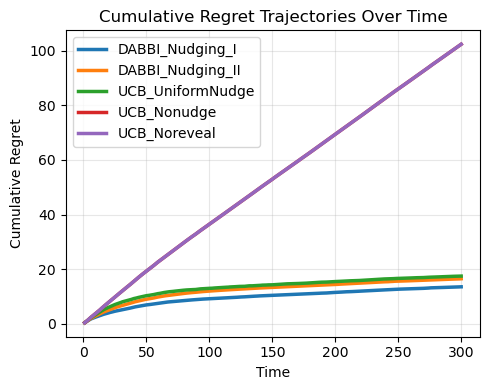

In [19]:
mean_regret_naive = df_naive_all.mean()
mean_regret_algorithm1 = df_algorithm1_all.mean()
mean_regret_algorithm2 = df_algorithm2_all.mean()
mean_regret_ucb_nonudge = df_ucb_nonudge_all.mean()
mean_regret_ucb_noreveal = df_ucb_noreveal_all.mean()
import matplotlib.pyplot as plt

time = np.arange(1, T + 1)

algorithms_data = [
        {
        'name': 'DABBI_Nudging_I',
        'mean_regret': mean_regret_algorithm1,
        # 'color': 'blue'
    },
    {
        'name': 'DABBI_Nudging_II',
        'mean_regret': mean_regret_algorithm2,
        # 'color': 'orange'
    },
        {
        'name': 'UCB_UniformNudge',
        'mean_regret': mean_regret_naive,
        # 'color': 'green'
    },
    {
        'name': 'UCB_Nonudge',
        'mean_regret': mean_regret_ucb_nonudge,
        # 'color': 'purple'
    },
    {
        'name': 'UCB_Noreveal',
        'mean_regret': mean_regret_ucb_noreveal,
        # 'color': 'red'
    }
    
]

# Plotting
plt.figure(figsize=(5, 4))

# Plot for each algorithm using pure Matplotlib
for alg in algorithms_data:
    plt.plot(
        time, 
        alg['mean_regret'], 
        # color=alg['color'], 
        label=alg['name'],
        linewidth=2.5 # Increased linewidth for better visibility
    )
    
    # NOTE: Confidence interval plotting (yerr) is commented out 
    # because the 'Upper' and 'Lower' bounds are not defined in the data 
    # (they are commented out in your input snippet).

# Set plot aesthetics - Switched to global plt. calls
# plt.xticks([20, 40, 60, 80, 100, 120, 140]) # Uncomment if specific ticks are needed
plt.xlabel('Time')
plt.ylabel('Cumulative Regret')
# We use plt.gca() to get the current Axes object to access tick_params
# plt.gca().tick_params(axis='both', which='major', labelsize=18)
plt.legend()
plt.grid(True, alpha=0.3)
plt.title('Cumulative Regret Trajectories Over Time')


# Display and Save
plt.tight_layout()
# plt.show()
plt.savefig("regretb20_unknown_10.png")

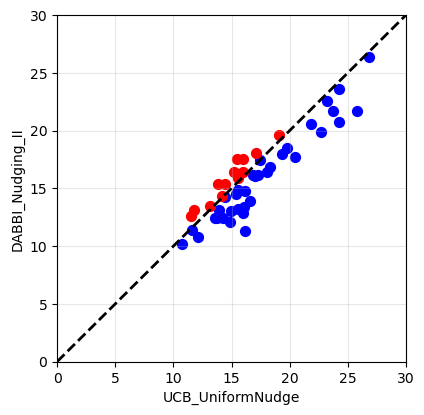

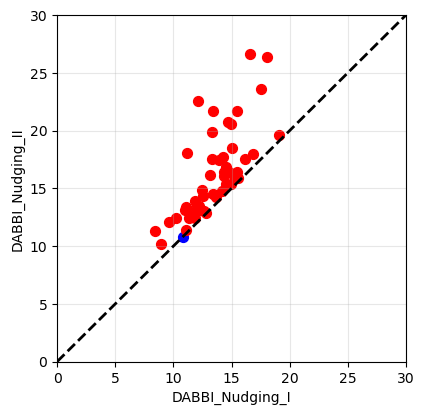

In [20]:
# Create dataframes
df_scatter1 = pd.DataFrame({
    'UCB_UniformNudge': naive_cumu_regret,
    'DABBI_Nudging_II': algorithm2_cumu_regret,
    'Group': np.where(np.greater(naive_cumu_regret, algorithm2_cumu_regret), 'Above Diagonal', 'Below Diagonal')
})

df_scatter2 = pd.DataFrame({
    'DABBI_Nudging_I': algorithm1_cumu_regret,
    'DABBI_Nudging_II': algorithm2_cumu_regret,
    'Group': np.where(np.greater(algorithm1_cumu_regret, algorithm2_cumu_regret), 'Above Diagonal', 'Below Diagonal')
})

# Function to plot scatter graphs
def plot_scatter(df, x_col, y_col, group_col, filename):
    colors = {'Above Diagonal': 'blue', 'Below Diagonal': 'red'}
    # fig, ax = plt.subplots(figsize=(5, 4))
    plt.figure(figsize=(4.5, 4.5))
    groups = df.groupby(group_col)

    for name, group in groups:
        plt.scatter(group[x_col], group[y_col], color=colors[name], s=50)
    plt.plot([0, 30], [0, 30], 'k--', linewidth=2)  # diagonal line
    plt.xlim(0, 30)
    plt.ylim(0, 30)
    plt.grid(True, alpha=0.3)
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    # ax.tick_params(axis='both', which='major', labelsize=18)
    plt.savefig(filename)  # Save the figure to file

# Plotting
plot_scatter(df_scatter1, 'UCB_UniformNudge', 'DABBI_Nudging_II', 'Group', "scatterb20_unknown_30_DABBI_Nudging_II_vs_UCB_UniformNudge.png")
plot_scatter(df_scatter2, 'DABBI_Nudging_I', 'DABBI_Nudging_II', 'Group', "scatterb20_unknown_30_DABBI_Nudging_II_vs_DABBI_Nudging_I.png")

plt.show()